# B2 — Village-level Flood Forecast (+24h / +48h)

**JalRakshak** · SIH26071 (MoES/IMD) · Team Blackbox

Har gaon ka apna risk level, 24 aur 48 ghante aage. Ye **forecast** hai — A2 RiskEngine
(jo abhi ka haal batata hai) se alag cheez.

| | |
|---|---|
| **Rainfall** | Open-Meteo historical archive (**ERA5** reanalysis), 30 Assam gaon, **2000-2025** |
| **Atmospheric** | NASA POWER (**MERRA-2** reanalysis) — pressure, humidity, dew point, temperature, wind, cloud |
| **Samples** | 283,980 gaon-din |
| **Labels** | hamara apna RiskEngine, aage ke din pe lagaya hua |
| **Split** | waqt se: train 2000-2017 · val 2018-2021 · test 2022-2025 |

---

### Ye notebook padhne se pehle teen baatein — inhe chhupaya nahi gaya hai

**1. Target "asli flood" nahi hai. Target hamara apna rule hai.**
Gaon-level flood ka labelled record hamare paas hai hi nahi. To label ye hai: *"us din
hamara RiskEngine kya bolta"*. Matlab model hamari risk-definition ko aage ke waqt mein
le jaana seekh raha hai — ye "flood ki bhavishyavani" ka daava NAHI hai.

**2. Label poori tarah barish ka function hai — isme koi chhupi hydrology nahi hai.**
River level asli gauge se nahi aata, wo 3-din ke cumulative rainfall se DERIVE hota hai
(decision D9). Algebra karo to poora rule do numbers pe simat jaata hai:

> `cum3 >= 192 mm` → river warning mark par · `cum3 >= 352 mm` → danger mark paar

To B2 ka asli kaam ek hi hai: **aage ki barish ka anumaan lagao**. Baaki sab arithmetic hai.

**3. "NWP" ka matlab yahan kya hai — aur kya NAHI.**
Dono source **reanalysis** hain: ek NWP model purane observations (satellite, station,
radiosonde) ke saath dobara chalaya gaya. Rainfall Open-Meteo archive (**ERA5**) se hai,
atmospheric variables NASA POWER (**MERRA-2**) se.

> Source kyun alag: pehle atmospheric variables bhi Open-Meteo se hi liye ja rahe the, par
> uska free tier request ko DATA VOLUME se tolta hai — 30 gaon x 8 variables x 26 saal ke
> liye ~6-7 ghante lagte (measure kiya: ghante mein 2-3 gaon, quota har ghante reset).
> NASA POWER wahi cheez 2 minute mein deta hai, bina API key ke.

To ye NWP-family ka data hai, par **operational forecast NAHI** —
reanalysis batata hai "us din mausam kaisa THA", forecast batata hai "kal kaisa HOGA",
aur forecast hamesha kam sateek hota hai. Isliye README mein ise "NWP forecast" nahi,
**"NWP-based reanalysis"** likha gaya hai.

**LEAKAGE ka niyam:** har feature sirf din `t` TAK ka hai. Reanalysis mein `t+1` ka matlab
"kal ka ASLI mausam" hai — usse feature banana model ko jawaab dikha dena hota, score
shaandaar aata aur deployment mein bekaar hota. `build_sequences()` ka slice `t` par
khatam hota hai; yahi is niyam ko lagoo karta hai.

**4. Data bahut imbalanced hai.** 26 saal ke 284,850 gaon-din mein:
green **98.60%** · yellow **1.33%** · red **0.07%** (kul 204 RED din).
Iska matlab **accuracy is problem mein bekaar metric hai** — "hamesha green bolo" se
98.2% accuracy aa jaati hai. Isliye neeche har jagah **per-class recall/precision** aur
**baseline se comparison** hai, accuracy ko headline nahi banaya gaya.

In [1]:
%matplotlib inline
import json, time, sys, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings("ignore")
sys.path.insert(0, "..") if Path.cwd().name == "notebooks" else sys.path.insert(0, ".")

import forecast_data as fd
import forecast_model as fm
import risk_rules as rr

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
MODELS = Path("models"); MODELS.mkdir(exist_ok=True)

DEVICE = fm.pick_device()
print("device:", DEVICE)
print("torch :", torch.__version__)

device: mps
torch : 2.8.0


## 1. Data + labels

`risk_rules.py` (RiskEngine ka Python port) se har gaon-din ka label banta hai.
Ye port asli PHP engine se **4,320 combinations pe verify kiya gaya hai**
(`python verify_against_php.py`) — dono bilkul match karte hain. Ye verification
optional nahi thi: usne do asli bug pakde (PHP ka rounding, aur `<= 80` vs `< 80`),
jinse 4,320 mein se 253 label galat ban rahe the.

In [2]:
t0 = time.time()
villages, dates, rain = fd.load_raw()
labels, cum3 = fd.build_labels(villages, rain)

# DO dataset — bilkul same split, same code, sirf features alag.
# Isse "NWP se fayda hua ya nahi" ka jawaab apples-to-apples milta hai.
d = fd.load_all(use_nwp=True)           # rainfall + NWP  (16 seq features)
d_rain = fd.load_all(use_nwp=False)     # sirf rainfall   (5 seq features, baaki zero)

tr, va, te = d["train"], d["val"], d["test"]
vi, ti = d["v_idx"], d["t_idx"]

print(f"villages {len(villages)}  days {len(dates)}  ({dates[0]} .. {dates[-1]})")
print(f"samples  {d['X_seq'].shape[0]:,}   seq {d['X_seq'].shape[1:]}  static {d['X_static'].shape[1]}")
print(f"NWP data complete for all villages: {d['nwp_used']}")
print(f"NWP features ({fd.N_NWP_FEATURES}): {', '.join(fd.NWP_FEATURE_NAMES)}")
print(f"split    train {tr.sum():,} | val {va.sum():,} | test {te.sum():,}     [{time.time()-t0:.0f}s]")

assert d["nwp_used"], (
    "NWP data adhoora hai. Pehle chalao: python fetch_nwp_data.py"
)


villages 30  days 9497  (2000-01-01 .. 2025-12-31)
samples  283,980   seq (30, 16)  static 11
NWP data complete for all villages: True
NWP features (11): pressure_delta_1d, pressure_delta_3d, humidity, dewpoint_depression, temp_mean, temp_range, wind_speed, wind_sin, wind_cos, cloud_cover, cloud_delta
split    train 196,380 | val 43,830 | test 43,770     [10s]


In [3]:
# --- label balance (yehi is problem ki sabse badi sachai hai) ---
rows = []
for name, m in (("train", tr), ("val", va), ("test", te)):
    for h in ("y24", "y48"):
        cnt = np.bincount(d[h][m], minlength=3)
        rows.append((name, h, *cnt, 100*cnt[2]/cnt.sum()))

print(f"{'split':6} {'horizon':8} {'green':>8} {'yellow':>7} {'red':>5}  {'red %':>6}")
for r in rows:
    print(f"{r[0]:6} {r[1]:8} {r[2]:8,} {r[3]:7,} {r[4]:5,}  {r[5]:6.3f}")

RED_TEST = int(np.bincount(d['y24'][te], minlength=3)[2])
print(f"\nTest set mein sirf {RED_TEST} RED samples hain. Un par nikle precision/recall")
print("shor bhare honge — isliye har table mein n bhi likha hai.")

split  horizon     green  yellow   red   red %
train  y24       193,654   2,578   148   0.075
train  y48       193,654   2,578   148   0.075
val    y24        43,351     468    11   0.025
val    y48        43,351     468    11   0.025
test   y24        42,995     730    45   0.103
test   y48        42,995     730    45   0.103

Test set mein sirf 45 RED samples hain. Un par nikle precision/recall
shor bhare honge — isliye har table mein n bhi likha hai.


## 2. Baselines — inhe harana hai

Koi bhi model tabhi kaam ka hai jab wo in se behtar ho. Teen baseline:

1. **Majority** — hamesha `green`. Accuracy ka jhooth yahin dikhta hai.
2. **Persistence (level)** — "kal wahi level jo aaj hai".
3. **Persistence (rainfall) → RiskEngine** — "kal utni hi barish jitni aaj", phir
   asli rule chala do. Ye sabse imaandaar baseline hai kyunki ye bilkul wahi kaam
   karta hai jo hamara model karega, bas bina kisi training ke.

In [4]:
def scores(y_true, y_pred):
    P, R, F, S = precision_recall_fscore_support(y_true, y_pred, labels=[0,1,2], zero_division=0)
    return {"acc": float((y_true == y_pred).mean()), "macro_f1": float(F.mean()),
            "precision": P.tolist(), "recall": R.tolist(), "f1": F.tolist(),
            "support": S.tolist()}

def show(tag, s):
    print(f"  {tag:34} acc={s['acc']:.4f}  macroF1={s['macro_f1']:.4f}   "
          f"red P={s['precision'][2]:.3f} R={s['recall'][2]:.3f} | "
          f"yellow P={s['precision'][1]:.3f} R={s['recall'][1]:.3f}")

def rule_from_rain(pred_r1, pred_r2, idx):
    """Predicted barish -> cum3 -> ASLI RiskEngine -> level. Yahi explainable hissa hai."""
    v_, t_ = vi[idx], ti[idx]
    c24 = rain[v_, t_-1] + rain[v_, t_] + pred_r1
    c48 = rain[v_, t_] + pred_r1 + pred_r2
    p24 = np.zeros(len(idx), np.int64); p48 = np.zeros(len(idx), np.int64)
    for k in range(len(idx)):
        v = villages[v_[k]]
        l1, _ = rr.assess(float(pred_r1[k]), float(c24[k]), v["elevation_m"], v["warning_m"], v["danger_m"])
        l2, _ = rr.assess(float(pred_r2[k]), float(c48[k]), v["elevation_m"], v["warning_m"], v["danger_m"])
        p24[k], p48[k] = rr.LEVEL_IDX[l1], rr.LEVEL_IDX[l2]
    return p24, p48

te_idx = np.where(te)[0]
va_idx = np.where(va)[0]
BASE = {}

print("TEST SET baselines")
for h, y in (("24h", d["y24"][te]), ("48h", d["y48"][te])):
    s = scores(y, np.zeros_like(y)); BASE[f"majority_{h}"] = s; show(f"majority (always green) {h}", s)
for h, y in (("24h", d["y24"][te]), ("48h", d["y48"][te])):
    s = scores(y, d["y_now"][te]); BASE[f"persistence_level_{h}"] = s; show(f"persistence of level {h}", s)

r_today = rain[vi[te_idx], ti[te_idx]]
p24, p48 = rule_from_rain(r_today, r_today, te_idx)
for h, y, p in (("24h", d["y24"][te], p24), ("48h", d["y48"][te], p48)):
    s = scores(y, p); BASE[f"persistence_rain_{h}"] = s; show(f"persistence of rainfall -> rule {h}", s)

TEST SET baselines
  majority (always green) 24h        acc=0.9823  macroF1=0.3304   red P=0.000 R=0.000 | yellow P=0.000 R=0.000
  majority (always green) 48h        acc=0.9823  macroF1=0.3304   red P=0.000 R=0.000 | yellow P=0.000 R=0.000
  persistence of level 24h           acc=0.9801  macroF1=0.6004   red P=0.400 R=0.400 | yellow P=0.411 R=0.411
  persistence of level 48h           acc=0.9760  macroF1=0.5113   red P=0.244 R=0.244 | yellow P=0.301 R=0.301
  persistence of rainfall -> rule 24h acc=0.9807  macroF1=0.5952   red P=0.340 R=0.400 | yellow P=0.431 R=0.425
  persistence of rainfall -> rule 48h acc=0.9763  macroF1=0.5106   red P=0.197 R=0.267 | yellow P=0.315 R=0.319


### Baseline se kya pata chala

`majority` ka accuracy **0.98** hai aur macro-F1 **0.33** — yaani accuracy poori tarah
gumrah karti hai. `persistence of rainfall -> RiskEngine` sabse mazboot baseline hai.
**Asli sawaal yahi hai: kya trained model isse behtar hai?**

## 3. Pehli koshish — seedha classifier (ye FAIL hui)

Sabse seedha tareeka: sequence daalo, teen class mein se ek nikaalo. Isko chhupaya nahi
gaya kyunki "kya kaam nahi aaya" natije ka hissa hai.

In [5]:
def make_tensors(mask, src=None):
    src = src if src is not None else d
    return (torch.from_numpy(src["X_seq"][mask]), torch.from_numpy(src["X_static"][mask]),
            torch.from_numpy(src["y24"][mask]), torch.from_numpy(src["y48"][mask]))

Xtr, Str, y24tr, y48tr = make_tensors(tr)
Xte, Ste, y24te, y48te = make_tensors(te)

def train_direct_classifier(power, epochs=6):
    torch.manual_seed(SEED)
    model = fm.DirectClassifierLSTM(n_seq=fd.N_SEQ_FEATURES, n_static=fd.N_STATIC_FEATURES).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    w24 = fm.class_weights(d["y24"][tr], power=power).to(DEVICE)
    w48 = fm.class_weights(d["y48"][tr], power=power).to(DEVICE)
    lf24, lf48 = nn.CrossEntropyLoss(weight=w24), nn.CrossEntropyLoss(weight=w48)
    n, BS = len(Xtr), 512
    for ep in range(epochs):
        model.train(); perm = torch.randperm(n)
        for i in range(0, n, BS):
            idx = perm[i:i+BS]
            a, b = model(Xtr[idx].to(DEVICE), Str[idx].to(DEVICE))
            loss = lf24(a, y24tr[idx].to(DEVICE)) + lf48(b, y48tr[idx].to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval(); A=[]; B=[]
    with torch.no_grad():
        for i in range(0, len(Xte), 8192):
            a, b = model(Xte[i:i+8192].to(DEVICE), Ste[i:i+8192].to(DEVICE))
            A.append(a.argmax(1).cpu()); B.append(b.argmax(1).cpu())
    return torch.cat(A).numpy(), torch.cat(B).numpy()

DIRECT = {}
for power, tag in ((0.5, "sqrt weights"), (1.0, "full inverse-freq weights")):
    t1 = time.time()
    a, b = train_direct_classifier(power)
    for h, y, p in (("24h", d["y24"][te], a), ("48h", d["y48"][te], b)):
        s = scores(y, p); DIRECT[f"direct_{tag.split()[0]}_{h}"] = s
        show(f"direct classifier ({tag}) {h}", s)
    print(f"     [{time.time()-t1:.0f}s]")

  direct classifier (sqrt weights) 24h acc=0.9786  macroF1=0.4832   red P=1.000 R=0.022 | yellow P=0.384 R=0.455
  direct classifier (sqrt weights) 48h acc=0.9805  macroF1=0.4335   red P=0.000 R=0.000 | yellow P=0.390 R=0.258
     [44s]


  direct classifier (full inverse-freq weights) 24h acc=0.8986  macroF1=0.4637   red P=0.162 R=0.622 | yellow P=0.108 R=0.692
  direct classifier (full inverse-freq weights) 48h acc=0.7852  macroF1=0.3737   red P=0.084 R=0.600 | yellow P=0.050 R=0.652
     [43s]


**Natija:** dono setting bekaar hain. `sqrt` weights pe RED recall lagbhag **0.00**
(model RED bolta hi nahi). Poore inverse-frequency weights pe RED recall to badh jaati
hai par precision **~0.07** — yaani har asli RED ke saath ~14 jhoothe RED. Flood system
mein false alarm apne aap mein khatra hai: do-teen jhoothe alert ke baad log agla ASLI
alert bhi ignore karte hain.

Dono `persistence of rainfall` baseline se bure hain. **Seedha classification chhod diya.**

## 4. Jo chala — barish predict karo, phir asli rule chalao

Label ki structure yaad karo: `label = RiskEngine(barish)`. Rule wala hissa
deterministic hai — usme seekhne ko kuch hai hi nahi. Mushkil sirf **barish** hai.

To model ko sirf wahi kaam diya: **aage do din ki barish**. Uske baad wahi RiskEngine
chalta hai jo dashboard chalata hai.

**Quantile kyun:** mean predict karne wala model extremes daba deta hai, aur flood mein
extreme din hi sab kuch hai. Model kai quantiles seekhta hai; kaunsa istemaal karna hai
wo **validation set** pe tay hota hai — test pe nahi.

### Do model, ek hi code

Yahan **do** model train hote hain, bilkul same split aur same loop se — sirf input
features alag:

| | features |
|---|---|
| **A — rainfall only** | 5 (barish, cum3, river-fraction, day-of-year sin/cos) |
| **B — rainfall + NWP** | 16 (upar wale 5 + 11 atmospheric) |

Ek hi cheez badalne se hi ye sawaal seedha jawaab deta hai: **NWP se fayda hua ya nahi?**

In [6]:
class RainDS(torch.utils.data.Dataset):
    def __init__(self, mask, src):
        idx = np.where(mask)[0]
        self.x = torch.from_numpy(src["X_seq"][idx])
        self.s = torch.from_numpy(src["X_static"][idx])
        r1 = rain[vi[idx], ti[idx]+1].astype(np.float32)
        r2 = rain[vi[idx], ti[idx]+2].astype(np.float32)
        self.y = torch.from_numpy(np.stack([np.log1p(r1), np.log1p(r2)], 1))
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.s[i], self.y[i]


def train_quantile_lstm(src, n_seq, tag, epochs=20):
    """Ek quantile-LSTM train karo. Dono variants ke liye BILKUL yahi code chalta hai."""
    ds_tr, ds_va = RainDS(tr, src), RainDS(va, src)
    dl_tr = torch.utils.data.DataLoader(ds_tr, batch_size=512, shuffle=True)

    torch.manual_seed(SEED); np.random.seed(SEED)
    model = fm.RainfallQuantileLSTM(n_seq=n_seq, n_static=fd.N_STATIC_FEATURES).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=2)

    hist = {"train": [], "val": []}
    best = (1e9, None)
    t0 = time.time()

    for ep in range(1, epochs+1):
        model.train(); tot = 0.0
        for xb, sb, yb in dl_tr:
            p = model(xb.to(DEVICE), sb.to(DEVICE))
            loss = fm.pinball_loss(p, yb.to(DEVICE), model.quantiles)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item()*len(xb)
        tr_loss = tot/len(ds_tr)

        model.eval(); tot = 0.0
        with torch.no_grad():
            for i in range(0, len(ds_va), 8192):
                xb, sb, yb = ds_va.x[i:i+8192], ds_va.s[i:i+8192], ds_va.y[i:i+8192]
                p = model(xb.to(DEVICE), sb.to(DEVICE))
                tot += fm.pinball_loss(p, yb.to(DEVICE), model.quantiles).item()*len(xb)
        va_loss = tot/len(ds_va)

        hist["train"].append(tr_loss); hist["val"].append(va_loss)
        sched.step(va_loss)
        if va_loss < best[0]:
            best = (va_loss, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
        if ep % 5 == 0 or ep == 1:
            print(f"    [{tag}] ep{ep:2d}  train={tr_loss:.4f}  val={va_loss:.4f}  [{time.time()-t0:.0f}s]")

    model.load_state_dict(best[1])
    print(f"  [{tag}] best val pinball {best[0]:.4f}   ({time.time()-t0:.0f}s)")
    return model, hist, best[0]

print("A — rainfall only")
model_rain, hist_rain, val_rain = train_quantile_lstm(d_rain, fd.N_SEQ_FEATURES, "rain-only")
print("\nB — rainfall + NWP")
model_nwp, hist_nwp, val_nwp = train_quantile_lstm(d, fd.N_SEQ_FEATURES, "rain+NWP")

print(f"\nvalidation pinball:  rainfall-only {val_rain:.4f}   rainfall+NWP {val_nwp:.4f}"
      f"   ({'NWP behtar' if val_nwp < val_rain else 'NWP se fayda nahi'})")

A — rainfall only


    [rain-only] ep 1  train=0.1997  val=0.1876  [10s]


    [rain-only] ep 5  train=0.1446  val=0.1672  [47s]


    [rain-only] ep10  train=0.1411  val=0.1569  [91s]


    [rain-only] ep15  train=0.1378  val=0.1560  [137s]


...

    [rain+NWP] ep 1  train=0.1936  val=0.1932  [11s]


    [rain+NWP] ep 5  train=0.1354  val=0.1555  [46s]


    [rain+NWP] ep10  train=0.1255  val=0.1609  [92s]


    [rain+NWP] ep15  train=0.1222  val=0.1608  [137s]


    [rain+NWP] ep20  train=0.1209  val=0.1642  [183s]
  [rain+NWP] best val pinball 0.1550   (183s)

validation pinball:  rainfall-only 0.1559   rainfall+NWP 0.1550   (NWP behtar)


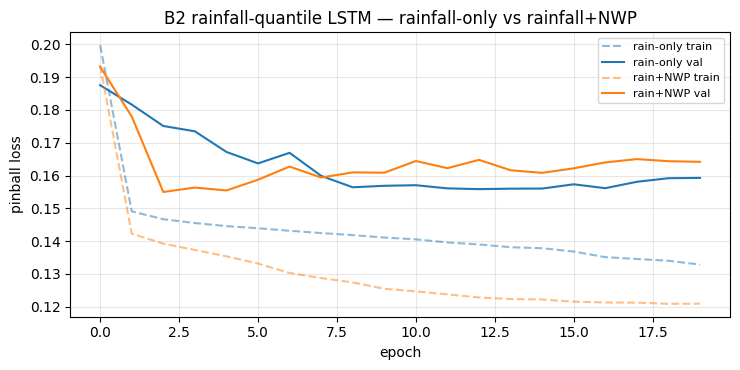

In [7]:
# --- training curve ---
plt.figure(figsize=(7.5,3.8))
plt.plot(hist_rain["train"], "--", color="C0", alpha=.5, label="rain-only train")
plt.plot(hist_rain["val"], "-", color="C0", label="rain-only val")
plt.plot(hist_nwp["train"], "--", color="C1", alpha=.5, label="rain+NWP train")
plt.plot(hist_nwp["val"], "-", color="C1", label="rain+NWP val")
plt.xlabel("epoch"); plt.ylabel("pinball loss"); plt.legend(fontsize=8)
plt.title("B2 rainfall-quantile LSTM — rainfall-only vs rainfall+NWP")
plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(OUT/"forecast_training_curves.png", dpi=130)
plt.show()

## 5. Quantile chuno — **validation** pe, test pe nahi

Har quantile ke liye: predicted barish -> RiskEngine -> level, phir validation macro-F1.
Jo jeete wahi test pe chalega. Ye alag cell isliye hai taaki saaf dikhe ki chunav
kis data pe hua.

In [8]:
def predict_rain(model_, src, mask, q_index):
    """Chune hue quantile par barish ka anumaan. model_ aur src saath chalte hain."""
    idx = np.where(mask)[0]
    X = torch.from_numpy(src["X_seq"][idx]); S = torch.from_numpy(src["X_static"][idx])
    outs = []
    model_.eval()
    with torch.no_grad():
        for i in range(0, len(X), 8192):
            outs.append(model_(X[i:i+8192].to(DEVICE), S[i:i+8192].to(DEVICE)).cpu())
    o = torch.cat(outs).numpy()
    return np.expm1(o[:, 0, q_index]).clip(0), np.expm1(o[:, 1, q_index]).clip(0)


def choose_quantile(model_, src, tag):
    """Har quantile ko rule se chala ke VALIDATION macro-F1 dekho; jo jeete wahi test par."""
    curve = {"q": [], "f24": [], "f48": []}
    for qi, q in enumerate(model_.quantiles):
        r1, r2 = predict_rain(model_, src, va, qi)
        pv24, pv48 = rule_from_rain(r1, r2, va_idx)
        curve["q"].append(q)
        curve["f24"].append(scores(d["y24"][va], pv24)["macro_f1"])
        curve["f48"].append(scores(d["y48"][va], pv48)["macro_f1"])
    q24 = int(np.argmax(curve["f24"])); q48 = int(np.argmax(curve["f48"]))
    print(f"  [{tag:9}] +24h q={model_.quantiles[q24]} (val F1 {curve['f24'][q24]:.4f})   "
          f"+48h q={model_.quantiles[q48]} (val F1 {curve['f48'][q48]:.4f})")
    return q24, q48, curve

print("quantile chunav — VALIDATION set par (test par nahi)")
Q24r, Q48r, curve_rain = choose_quantile(model_rain, d_rain, "rain-only")
Q24, Q48, val_curve = choose_quantile(model_nwp, d, "rain+NWP")

model = model_nwp   # jo ship hoga

quantile chunav — VALIDATION set par (test par nahi)


  [rain-only] +24h q=0.9 (val F1 0.5509)   +48h q=0.9 (val F1 0.4415)


  [rain+NWP ] +24h q=0.97 (val F1 0.5602)   +48h q=0.97 (val F1 0.4688)


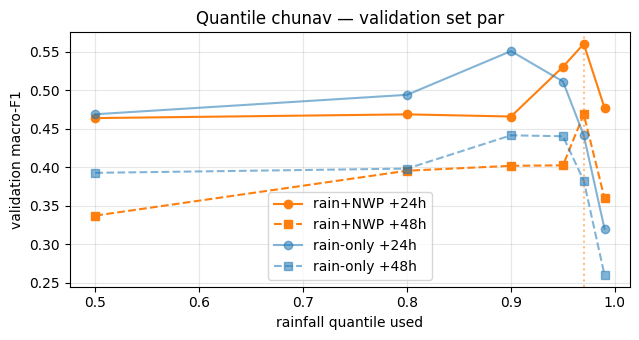

In [9]:
plt.figure(figsize=(6.5,3.5))
plt.plot(val_curve["q"], val_curve["f24"], "o-", color="C1", label="rain+NWP +24h")
plt.plot(val_curve["q"], val_curve["f48"], "s-", color="C1", ls="--", label="rain+NWP +48h")
plt.plot(curve_rain["q"], curve_rain["f24"], "o-", color="C0", alpha=.55, label="rain-only +24h")
plt.plot(curve_rain["q"], curve_rain["f48"], "s-", color="C0", alpha=.55, ls="--", label="rain-only +48h")
plt.axvline(model_nwp.quantiles[Q24], color="C1", ls=":", alpha=.5)
plt.xlabel("rainfall quantile used"); plt.ylabel("validation macro-F1")
plt.title("Quantile chunav — validation set par")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.savefig(OUT/"forecast_quantile_selection.png", dpi=130)
plt.show()

## 6. Test set — asli numbers

Test = **2022-01-01 se 2025-12-29**, jo training aur quantile-chunav dono se bahar hai.
2022 ka asli Assam flood isme aata hai.

In [10]:
def eval_model(model_, src, q24, q48):
    r1_24, _ = predict_rain(model_, src, te, q24)
    r1_48, r2_48 = predict_rain(model_, src, te, q48)
    p24, _ = rule_from_rain(r1_24, r1_24, te_idx)
    _, p48 = rule_from_rain(r1_48, r2_48, te_idx)
    return p24, p48

p24r, p48r = eval_model(model_rain, d_rain, Q24r, Q48r)
p24, p48 = eval_model(model_nwp, d, Q24, Q48)

MODEL, MODEL_RAIN = {}, {}
print("TEST SET")
for h, y, p in (("24h", d["y24"][te], p24r), ("48h", d["y48"][te], p48r)):
    sc = scores(y, p); MODEL_RAIN[f"lstm_{h}"] = sc; show(f"A  rainfall-only  -> rule {h}", sc)
for h, y, p in (("24h", d["y24"][te], p24), ("48h", d["y48"][te], p48)):
    sc = scores(y, p); MODEL[f"lstm_{h}"] = sc; show(f"B  rainfall+NWP   -> rule {h}", sc)

print("\nper-class detail")
for h, y, p in (("24h", d["y24"][te], p24), ("48h", d["y48"][te], p48)):
    s = MODEL[f"lstm_{h}"]
    print(f"\n  +{h}   accuracy {s['acc']:.4f}   macro-F1 {s['macro_f1']:.4f}")
    print(f"  {'class':8} {'precision':>10} {'recall':>8} {'f1':>7} {'support':>9}")
    for i, lab in enumerate(["green","yellow","red"]):
        print(f"  {lab:8} {s['precision'][i]:10.3f} {s['recall'][i]:8.3f} {s['f1'][i]:7.3f} {s['support'][i]:9,}")

TEST SET
  A  rainfall-only  -> rule 24h      acc=0.9806  macroF1=0.6259   red P=0.625 R=0.333 | yellow P=0.432 R=0.475
  A  rainfall-only  -> rule 48h      acc=0.9816  macroF1=0.5028   red P=0.538 R=0.156 | yellow P=0.426 R=0.204
  B  rainfall+NWP   -> rule 24h      acc=0.9818  macroF1=0.6091   red P=0.786 R=0.244 | yellow P=0.458 R=0.468
  B  rainfall+NWP   -> rule 48h      acc=0.9624  macroF1=0.4827   red P=0.500 R=0.089 | yellow P=0.227 R=0.518

per-class detail

  +24h   accuracy 0.9818   macro-F1 0.6091
  class     precision   recall      f1   support
  green         0.991    0.991   0.991    42,995
  yellow        0.458    0.468   0.463       730
  red           0.786    0.244   0.373        45

  +48h   accuracy 0.9624   macro-F1 0.4827
  class     precision   recall      f1   support
  green         0.991    0.971   0.981    42,995
  yellow        0.227    0.518   0.316       730
  red           0.500    0.089   0.151        45


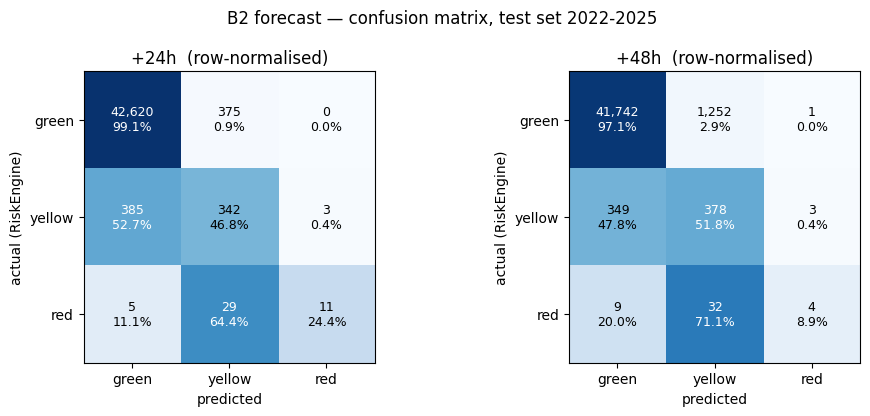

In [11]:
# --- confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (h, y, p) in zip(axes, (("+24h", d["y24"][te], p24), ("+48h", d["y48"][te], p48))):
    cm = confusion_matrix(y, p, labels=[0,1,2])
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i,j]:,}\n{100*cmn[i,j]:.1f}%", ha="center", va="center",
                    fontsize=9, color="white" if cmn[i,j] > .5 else "black")
    ax.set_xticks(range(3)); ax.set_xticklabels(["green","yellow","red"])
    ax.set_yticks(range(3)); ax.set_yticklabels(["green","yellow","red"])
    ax.set_xlabel("predicted"); ax.set_ylabel("actual (RiskEngine)")
    ax.set_title(f"{h}  (row-normalised)")
fig.suptitle("B2 forecast — confusion matrix, test set 2022-2025")
plt.tight_layout()
plt.savefig(OUT/"forecast_confusion.png", dpi=130)
plt.show()

## 7. Model bनाम baseline — asli faisla

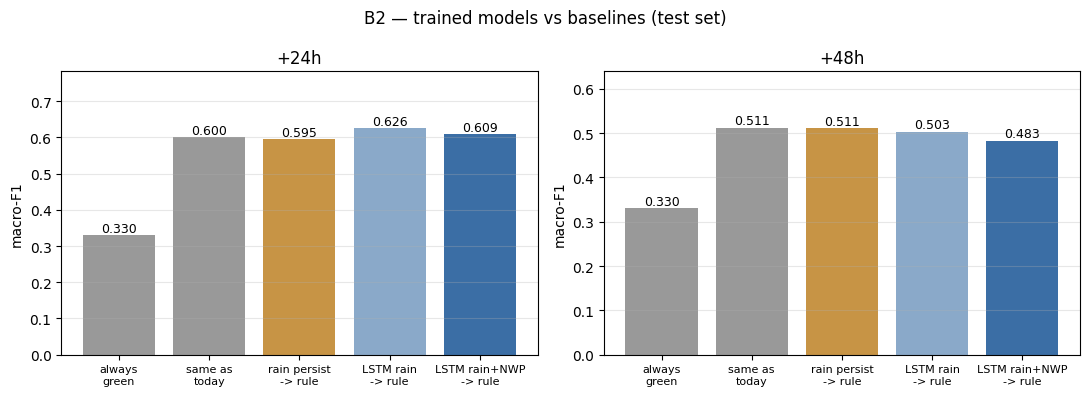

MODEL SELECTION — validation par, test par NAHI
  val macro-F1 (chosen q):  rain-only 0.5509/0.4415   rain+NWP 0.5602/0.4688
  -> validation ne chuna: rain+NWP  (yehi ship hota hai)

FAISLA — kya NWP se persistence hara?
  +24h:  rainfall-only 0.6259  |  rainfall+NWP 0.6091  (-0.0168 NWP se)
        best baseline 0.6004  ->  BEAT KIYA (+0.0087)
  +48h:  rainfall-only 0.5028  |  rainfall+NWP 0.4827  (-0.0201 NWP se)
        best baseline 0.5113  ->  NAHI HARA (-0.0287)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels_ = ["always\ngreen", "same as\ntoday", "rain persist\n-> rule",
           "LSTM rain\n-> rule", "LSTM rain+NWP\n-> rule"]
for ax, h in zip(axes, ("24h", "48h")):
    vals = [BASE[f"majority_{h}"]["macro_f1"], BASE[f"persistence_level_{h}"]["macro_f1"],
            BASE[f"persistence_rain_{h}"]["macro_f1"], MODEL_RAIN[f"lstm_{h}"]["macro_f1"],
            MODEL[f"lstm_{h}"]["macro_f1"]]
    bars = ax.bar(labels_, vals, color=["#999","#999","#c79445","#8aa9c9","#3b6ea5"])
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+.008, f"{v:.3f}", ha="center", fontsize=9)
    ax.set_ylim(0, max(vals)*1.25); ax.set_ylabel("macro-F1"); ax.set_title(f"+{h}")
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=.3)
fig.suptitle("B2 — trained models vs baselines (test set)")
plt.tight_layout()
plt.savefig(OUT/"forecast_baselines.png", dpi=130)
plt.show()

print("MODEL SELECTION — validation par, test par NAHI")
print(f"  val macro-F1 (chosen q):  rain-only {curve_rain['f24'][Q24r]:.4f}/{curve_rain['f48'][Q48r]:.4f}"
      f"   rain+NWP {val_curve['f24'][Q24]:.4f}/{val_curve['f48'][Q48]:.4f}")
_sel = "rain+NWP" if (val_curve['f24'][Q24] + val_curve['f48'][Q48]) > (curve_rain['f24'][Q24r] + curve_rain['f48'][Q48r]) else "rain-only"
print(f"  -> validation ne chuna: {_sel}  (yehi ship hota hai)")

print("\nFAISLA — kya NWP se persistence hara?")
for h in ("24h", "48h"):
    best_base = max(BASE[f"persistence_rain_{h}"]["macro_f1"], BASE[f"persistence_level_{h}"]["macro_f1"])
    a = MODEL_RAIN[f"lstm_{h}"]["macro_f1"]; b_ = MODEL[f"lstm_{h}"]["macro_f1"]
    print(f"  +{h}:  rainfall-only {a:.4f}  |  rainfall+NWP {b_:.4f}  ({b_-a:+.4f} NWP se)")
    print(f"        best baseline {best_base:.4f}  ->  "
          f"{'BEAT KIYA' if b_ > best_base else 'NAHI HARA'} ({b_-best_base:+.4f})")

## 8. Save

In [13]:
torch.save({
    "state_dict": model_nwp.state_dict(),
    "quantiles": model_nwp.quantiles,
    "features": "rainfall + NWP (ERA5 reanalysis)",
    "q_index_24": Q24, "q_index_48": Q48,
    "seq_len": fd.SEQ_LEN,
    "n_seq_features": fd.N_SEQ_FEATURES,
    "n_static_features": fd.N_STATIC_FEATURES,
}, MODELS/"forecast_lstm.pt")

metrics = {
    "task": "village-level flood risk forecast (+24h / +48h)",
    "target": "RiskEngine level on the future day (NOT observed flooding)",
    "data": {
        "source": "rainfall: Open-Meteo archive (ERA5) | atmospheric: NASA POWER (MERRA-2)",
        "villages": len(villages), "days": len(dates),
        "date_range": [dates[0], dates[-1]],
        "samples": int(d["X_seq"].shape[0]),
        "split": {"train": int(tr.sum()), "val": int(va.sum()), "test": int(te.sum())},
        "split_dates": {"train_end": fd.TRAIN_END, "val_end": fd.VAL_END},
    },
    "class_balance_test": {
        "green": int(np.bincount(d["y24"][te], minlength=3)[0]),
        "yellow": int(np.bincount(d["y24"][te], minlength=3)[1]),
        "red": int(np.bincount(d["y24"][te], minlength=3)[2]),
    },
    "model": "LSTM(2x64) -> rainfall quantile -> RiskEngine rule",
    "features": {
        "sequence": fd.N_SEQ_FEATURES,
        "rainfall": fd.N_RAIN_FEATURES,
        "nwp": fd.N_NWP_FEATURES,
        "nwp_names": fd.NWP_FEATURE_NAMES,
        "nwp_source": "NASA POWER = MERRA-2 reanalysis (NWP-based), NOT operational forecast",
        "rainfall_source": "Open-Meteo archive = ERA5 reanalysis",
        "inference_source": "Open-Meteo forecast API (operational) — train/serve mismatch, see README",
        "leakage_rule": "features use day t and earlier only; never t+1 / t+2",
    },
    "params": int(sum(p.numel() for p in model_nwp.parameters())),
    "quantiles": model_nwp.quantiles,
    "chosen_quantile": {"h24": model_nwp.quantiles[Q24], "h48": model_nwp.quantiles[Q48]},
    "ablation_rainfall_only": {
        "test": MODEL_RAIN,
        "chosen_quantile": {"h24": model_rain.quantiles[Q24r], "h48": model_rain.quantiles[Q48r]},
        "best_val_pinball": float(val_rain),
    },
    "chosen_on": "validation set (2018-2021)",
    "best_val_pinball": float(val_nwp),
    "test": {k: v for k, v in MODEL.items()},
    "baselines_test": BASE,
    "direct_classifier_test": DIRECT,
    "class_order": ["green", "yellow", "red"],
}
(OUT/"forecast_metrics.json").write_text(json.dumps(metrics, indent=2))
print("saved:")
print("  models/forecast_lstm.pt")
print("  outputs/forecast_metrics.json")
for p_ in ["forecast_training_curves.png","forecast_quantile_selection.png",
           "forecast_confusion.png","forecast_baselines.png"]:
    print("  outputs/"+p_)

saved:
  models/forecast_lstm.pt
  outputs/forecast_metrics.json
  outputs/forecast_training_curves.png
  outputs/forecast_quantile_selection.png
  outputs/forecast_confusion.png
  outputs/forecast_baselines.png
